# Import necessary libraries

In [1]:
import requests
import json
import pandas as pd 
import os
import time
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib.ticker import MultipleLocator
import networkx as nx
import warnings
warnings.simplefilter("ignore")

# Publications Retrieval

In [2]:
# Define the path for local file storage
local_file_path = 'api_responses.json'

def get_author_publications(author_name):
    # Initialize the starting index and the number of results per call
    f = 0
    h = 500
    all_publications = []
    
    # Initialize data as an empty dictionary
    # Keys : Authors
    # Values : JSON responses 
    data = {}

    # Load existing data from the local file if it exists
    if os.path.exists(local_file_path):
        with open(local_file_path, 'r') as file:
            data = json.load(file)
        
        # Check if the author_name is already in the local file
        if author_name in data:
            return data[author_name]

    # If no existing data for the author in the local file, proceed with API requests
    while True:
        # Construct the query URL with the current starting index
        url = f"https://dblp.org/search/publ/api?q={author_name}&format=json&h={h}&f={f}"
        
        # Send a GET request to the DBLP API
        r = requests.get(url)
        
        # Check the response
        if r.status_code == 200:
            # Load the JSON response
            j = json.loads(r.text)

            # Extract the hits from the JSON response
            hits = j['result']['hits'].get('hit', [])
            
            # If no hits are returned, break the loop
            if not hits:
                break

            # Iterate through each hit
            for hit in hits:
                # Extract the authors for the current hit
                authors = hit['info']['authors']['author']
                
                # Convert authors to a list if it's a dictionary (i.e., single-author publication)
                if isinstance(authors, dict):
                    authors = [authors]

                # Check if the desired author is in the list of authors for this hit
                if any(author['text'] == author_name for author in authors):
                    all_publications.append(hit)

            # Increment the starting index for the next API call
            f += h
        
        else:
            print("Error:", r.status_code)
            print("Response content:", r.content)
            break
        
        # Add a delay to avoid hitting API rate limits
        time.sleep(1)

    # At the end of the function, update the local file with the retrieved data for the author_name
    # No need for API request next time
    data[author_name] = all_publications
    
    # Save the updated data to the local file
    with open(local_file_path, 'w') as file:
        json.dump(data, file)
    
    return all_publications

In [3]:
# Test the function with a specific author
author_name = "Ling Shao 0001"
author_pubs = get_author_publications(author_name)
if author_pubs is not None:
    print(f"{author_name} has {len(author_pubs)} publications.")
else:
    print("Failed to retrieve publication count.")

Ling Shao 0001 has 906 publications.


In [4]:
# Study 3 specific authors 
authors = ["Ling Shao 0001", "Yonina C. Eldar", "Rolf Drechsler"]
author_pubs = [get_author_publications(authors[i]) for i in range(len(authors))]

In [5]:
# Show the number of publications for each author
for author, pubs in zip(authors, author_pubs):
    if pubs is not None:
        print(f"{author} has {len(pubs)} publications.")
    else:
        print("Failed to retrieve publication count.")

Ling Shao 0001 has 906 publications.
Yonina C. Eldar has 960 publications.
Rolf Drechsler has 931 publications.


In [6]:
# Convert JSON objects to DataFrame
merged_df = [pd.json_normalize(author_pubs[i]) for i in range(len(author_pubs))]

In [7]:
# Take a look at a dataframe
merged_df[0].head()

,@score,@id,url,info.authors.author,info.title,info.venue,info.volume,info.number,info.pages,info.year,info.type,info.access,info.key,info.doi,info.ee,info.url,info.publisher,info.authors.author.@pid,info.authors.author.text
0,18,3222219,URL#3222219,"[{'@pid': '33/5593', 'text': 'Nikolaos V. Boul...",Introduction of New Associate Editors.,IEEE Trans. Circuits Syst. Video Technol.,26,2,253-263,2016,Journal Articles,closed,journals/tcsv/BoulgourisBCCCR16,10.1109/TCSVT.2016.2518782,https://doi.org/10.1109/TCSVT.2016.2518782,https://dblp.org/rec/journals/tcsv/BoulgourisB...,NaN,NaN,NaN
1,13,2187507,URL#2187507,"[{'@pid': '202/2128', 'text': 'Abdelrahman Abd...",NTIRE 2019 Challenge on Real Image Denoising: ...,CVPR Workshops,NaN,NaN,2197-2210,2019,Conference and Workshop Papers,open,conf/cvpr/AbdelhamedTB19,10.1109/CVPRW.2019.00273,http://openaccess.thecvf.com/content_CVPRW_201...,https://dblp.org/rec/conf/cvpr/AbdelhamedTB19,NaN,NaN,NaN
2,11,1363569,URL#1363569,"[{'@pid': '79/1648', 'text': 'Matej Kristan'},...",The Ninth Visual Object Tracking VOT2021 Chall...,ICCVW,NaN,NaN,2711-2738,2021,Conference and Workshop Papers,closed,conf/iccvw/KristanMLFPKCDZ21,10.1109/ICCVW54120.2021.00305,https://doi.org/10.1109/ICCVW54120.2021.00305,https://dblp.org/rec/conf/iccvw/KristanMLFPKCDZ21,NaN,NaN,NaN
3,10,1713593,URL#1713593,"[{'@pid': '25/364', 'text': 'Yingkun Hou'}, {'...",NLH: A Blind Pixel-Level Non-Local Method for ...,IEEE Trans. Image Process.,29,NaN,5121-5135,2020,Journal Articles,closed,journals/tip/HouXLLLZS20,10.1109/TIP.2020.2980116,https://doi.org/10.1109/TIP.2020.2980116,https://dblp.org/rec/journals/tip/HouXLLLZS20,NaN,NaN,NaN
4,10,2134836,URL#2134836,"[{'@pid': '49/10082', 'text': 'Lingli Zhou'}, ...",Depth Embedded Recurrent Predictive Parsing Ne...,IEEE Trans. Intell. Transp. Syst.,20,12,4643-4654,2019,Journal Articles,closed,journals/tits/ZhouZLSY19,10.1109/TITS.2019.2909053,https://doi.org/10.1109/TITS.2019.2909053,https://dblp.org/rec/journals/tits/ZhouZLSY19,NaN,NaN,NaN


# Exploratory Data Analysis

In [8]:
# Create a list with the publication counts for each author
pubs_count = [len(author_pubs[i]) for i in range(len(author_pubs))]
pubs_count

[906, 960, 931]

In [9]:
# Sort authors and pubs_count in descending order based on pubs_count
sorted_data = sorted(zip(authors, pubs_count), key=lambda x: x[1], reverse=True)
sorted_authors = [item[0] for item in sorted_data]
sorted_pubs_count = [item[1] for item in sorted_data]

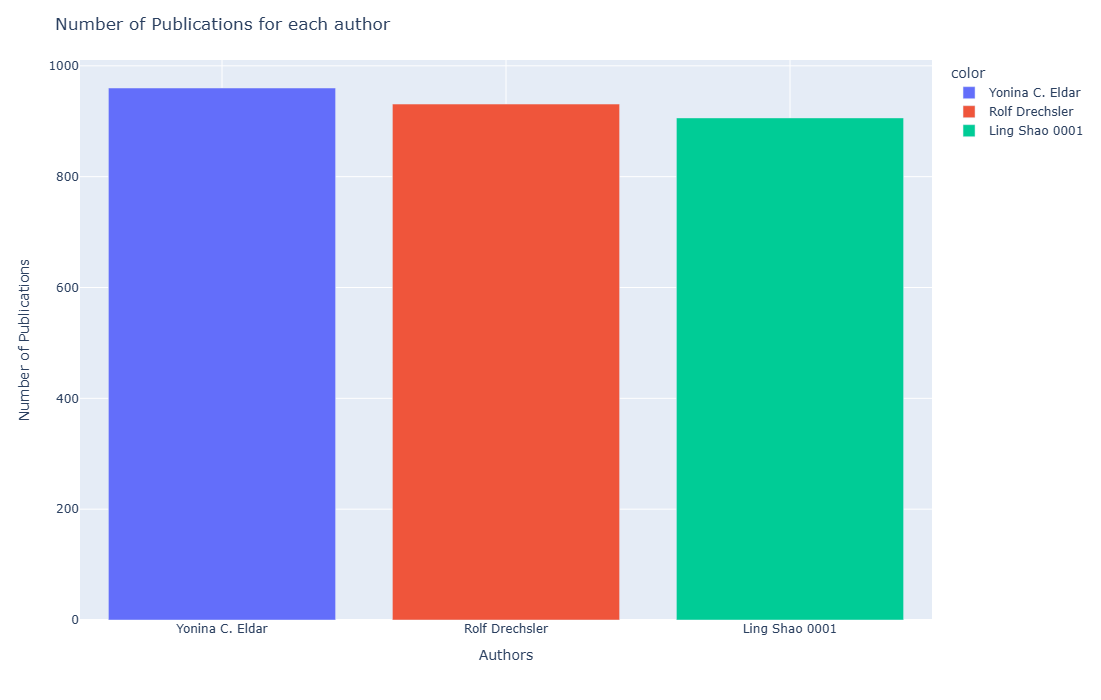

In [10]:
# Visualize the number of publications for each author using 'plotly.express'
fig = px.bar(x=sorted_authors, y=sorted_pubs_count, color=sorted_authors)

layout = dict(
autosize=False,
title=r"Number of Publications for each author",
xaxis=dict(title='Authors', showgrid=True),
yaxis=dict(title='Number of Publications'),
width=1000,
height=700,
)

fig.update_layout(layout).show()

In [11]:
# Create a list with the publication count per year for each author
pubs_time = [merged_df[i].groupby(['info.year'])['@id'].count().reset_index() for i in range(len(merged_df))]
pubs_time[0]

,info.year,@id
0,2004,1
1,2006,4
2,2007,12
3,2008,5
4,2009,5
5,2010,12
6,2011,18
7,2012,12
8,2013,31
9,2014,38


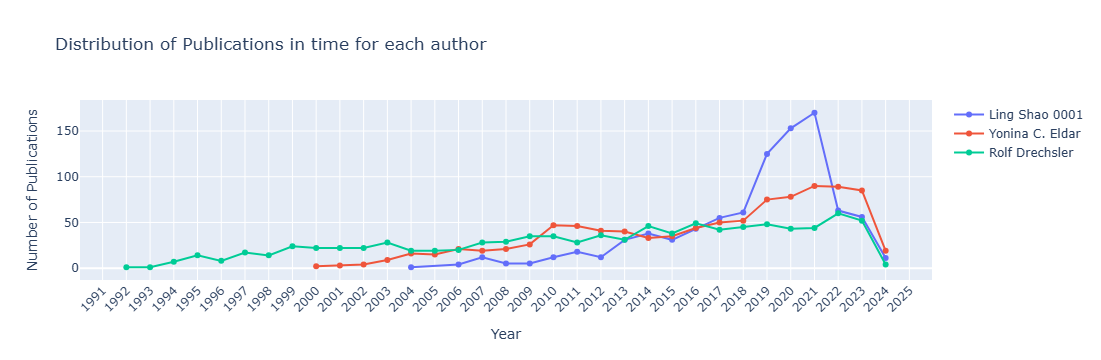

In [12]:
# Visualize the number of publications in time for each author
fig = go.Figure()

for df, auth in zip(pubs_time, authors):
    # Convert 'info.year' column to numeric for completeness shake
    df["info.year"] = pd.to_numeric(df["info.year"])
    fig.add_trace(
        go.Scatter(
            x=df["info.year"],
            y=df["@id"],
            mode="lines+markers",
            name=auth
        )
    )
    
fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Number of Publications",
    title="Distribution of Publications in time for each author",
    xaxis=dict(
        tickangle=-45,
        tickmode='linear',
        dtick=1
    )
)

fig.show()

In [13]:
# Create a list with the publication count for each type for each author
pubs_type = [merged_df[i].groupby(['info.type'])['@id'].count().reset_index() for i in range(len(merged_df))]
pubs_type[2]

,info.type,@id
0,Books and Theses,14
1,Conference and Workshop Papers,719
2,Data and Artifacts,3
3,Editorship,15
4,Informal and Other Publications,25
5,Journal Articles,150
6,Parts in Books or Collections,5


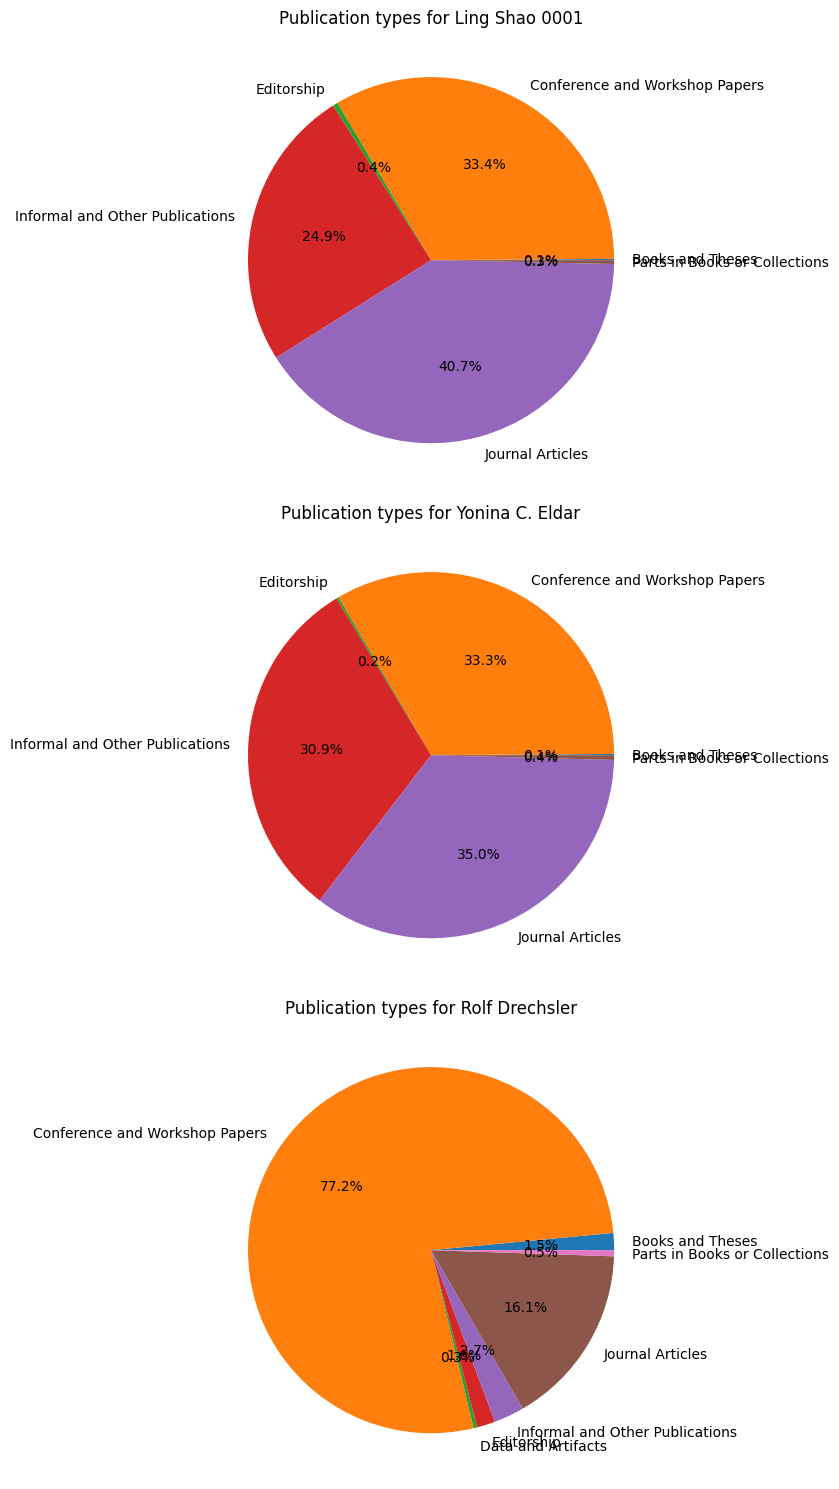

In [14]:
# Create subplots for each author for each publication type using 'matplotlib.pyplot'
fig, ax = plt.subplots(nrows=len(authors), ncols=1, figsize=(10, 15))

for i, (df, auth) in enumerate(zip(pubs_type, authors)):
    ax[i].pie(df['@id'], labels=df['info.type'], autopct='%1.1f%%')
    ax[i].set_title(f"Publication types for {auth}")

plt.tight_layout()
plt.show()

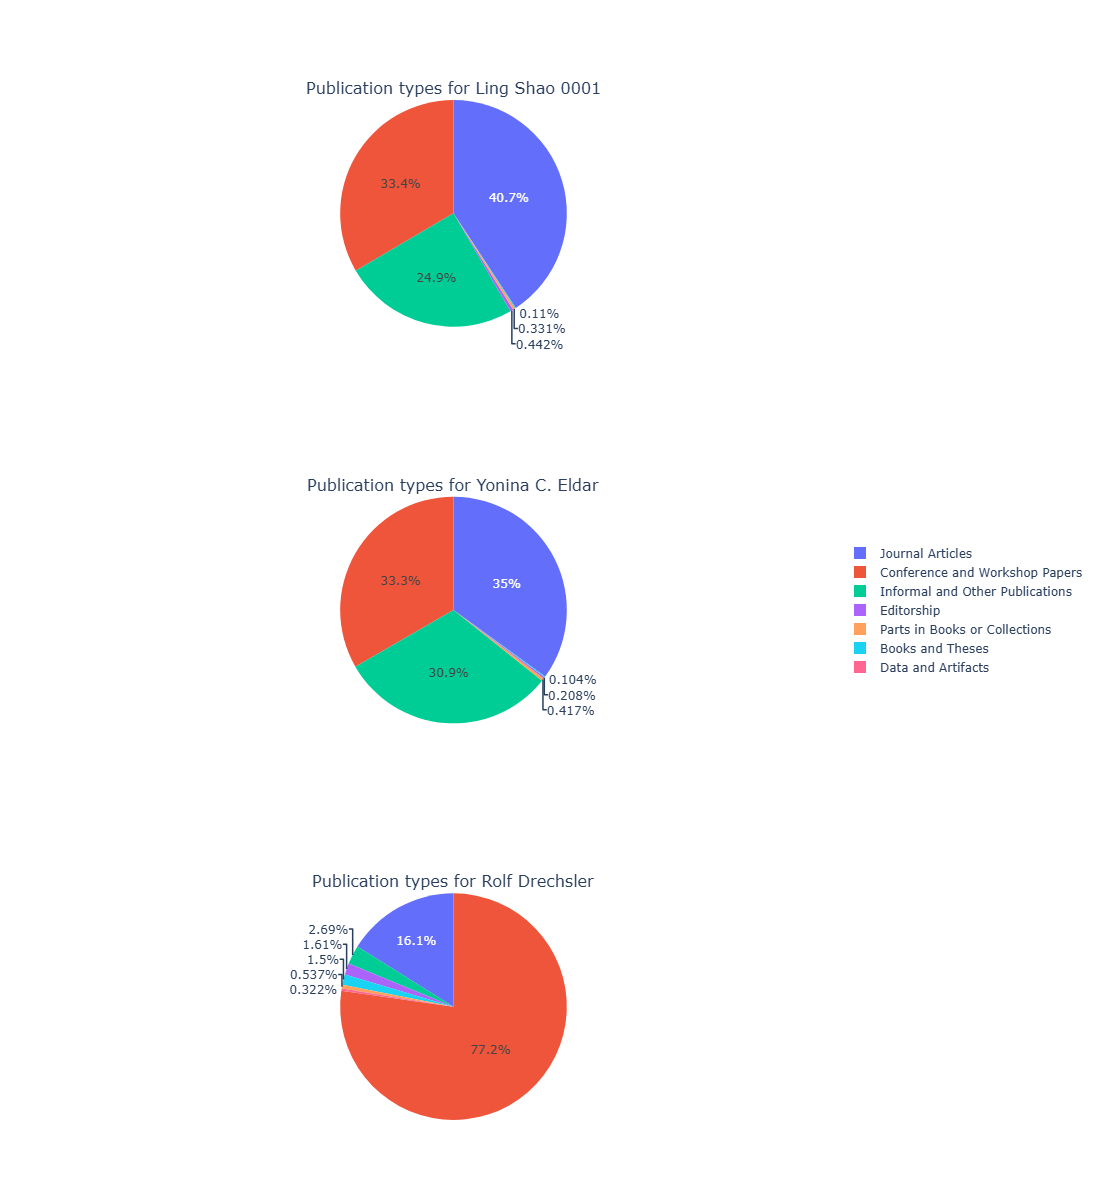

In [15]:
# Visualize the publication types for each author using 'plotly.graph_objects'
fig = make_subplots(rows=len(authors), cols=1,
                    subplot_titles=[f"Publication types for {auth}" for auth in authors],
                    specs=[[{'type': 'domain'}], [{'type': 'domain'}], [{'type': 'domain'}]])

for i, (df, auth) in enumerate(zip(pubs_type, authors)):
    fig.add_trace(
        go.Pie(labels=df['info.type'], values=df['@id'], name=auth),
        row=i+1, col=1   
    )

        
fig.update_layout(
    height=1200,
    width=800,
    legend=dict(
        y=0.5,  
        yanchor='middle',  
        x=1.5,  
        xanchor='center'  
    )
)

fig.show()

In [16]:
# Convert lists in 'info.venue' column for each dataframe to strings
for df in merged_df:
    df['info.venue'] = df['info.venue'].apply(lambda x: ', '.join(x) if isinstance(x, list) else x)

In [17]:
# Create a list with the publication count for each venue for each author
venue_counts = [merged_df[i].groupby(['info.venue'])['@id'].count().reset_index() for i in range(len(merged_df))]
venue_counts[0]

,info.venue,@id
0,AAAI,13
1,ACCV,2
2,ACIVS,1
3,ACM Multimedia,16
4,ACPR,1
...,...,...
99,Signal Process. Image Commun.,1
100,VCIP,1
101,VLDB J.,3
102,WACV,6


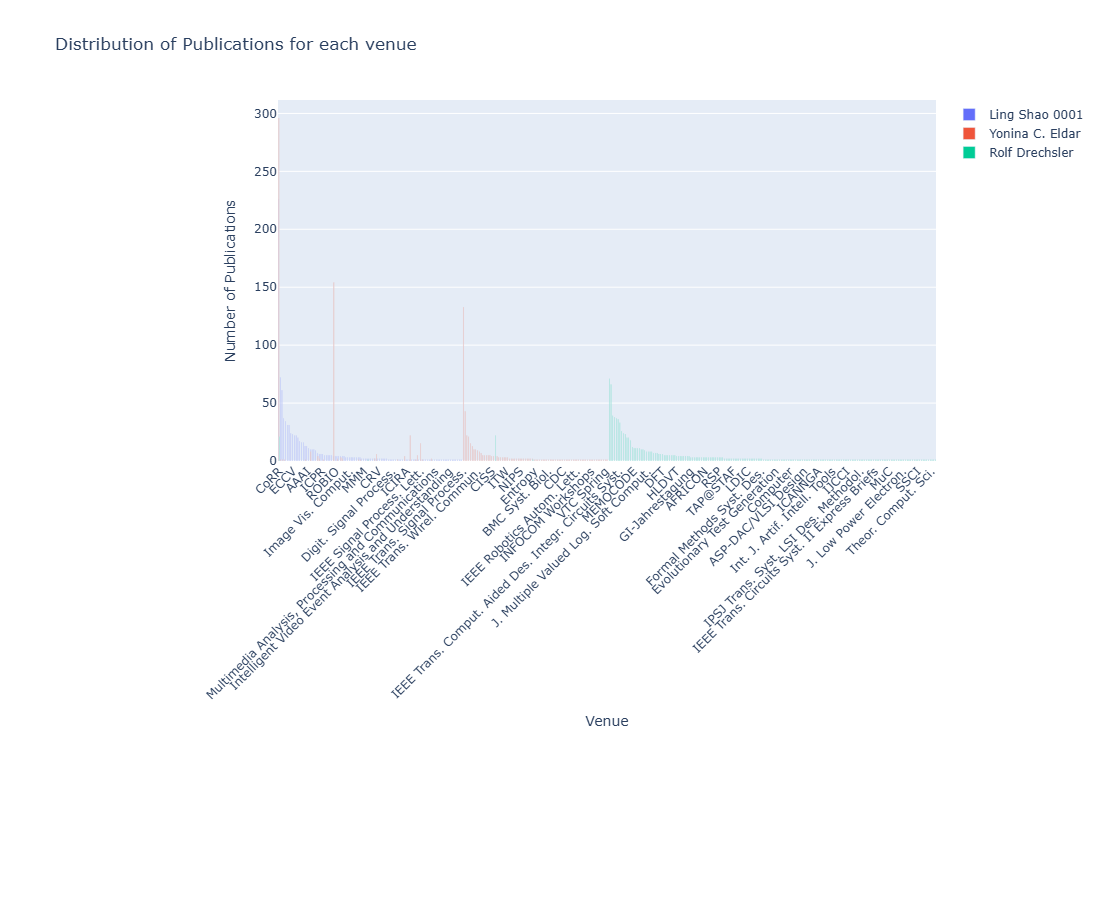

In [18]:
# Visualize the distribution of publications for each venue
fig = go.Figure()
for df, auth in zip(venue_counts, authors):
    df_sorted = df.sort_values(by="@id", ascending=False)
    fig.add_trace(
        go.Bar(
            x=df_sorted["info.venue"],
            y=df_sorted["@id"],
            name=auth
        )
    )
    
fig.update_layout(
    xaxis_title="Venue",
    yaxis_title="Number of Publications",
    title="Distribution of Publications for each venue",
    xaxis_tickangle=-45, 
    bargap=0.2,
    height=900,
    width=1300
)

fig.show()

In [19]:
# Create a list with the venue count per year for each author
venue_year = [merged_df[i].groupby(['info.year', 'info.venue']).size().reset_index(name='count') for i in range(len(merged_df))]
venue_year[0]

,info.year,info.venue,count
0,2004,ECCV Workshops CVAMIA and MMBIA,1
1,2006,EUSIPCO,1
2,2006,ICME,1
3,2006,J. Vis. Commun. Image Represent.,1
4,2006,Pattern Recognit.,1
...,...,...,...
298,2024,CoRR,4
299,2024,IEEE Trans. Image Process.,1
300,2024,IEEE Trans. Neural Networks Learn. Syst.,3
301,2024,IEEE Trans. Pattern Anal. Mach. Intell.,2


In [20]:
# Create a list with the most popular venues per year for each author
most_popular_venues = [venue_year[i].loc[venue_year[i].groupby('info.year')['count'].idxmax()] for i in range(len(venue_year))]
most_popular_venues[0]

,info.year,info.venue,count
0,2004,ECCV Workshops CVAMIA and MMBIA,1
1,2006,EUSIPCO,1
8,2007,ICME,3
14,2008,ICASSP,2
19,2009,CRV,2
22,2010,CIVR,4
30,2011,CoRR,2
49,2012,Pattern Recognit. Lett.,3
58,2013,IEEE Trans. Cybern.,3
70,2014,BMVC,4


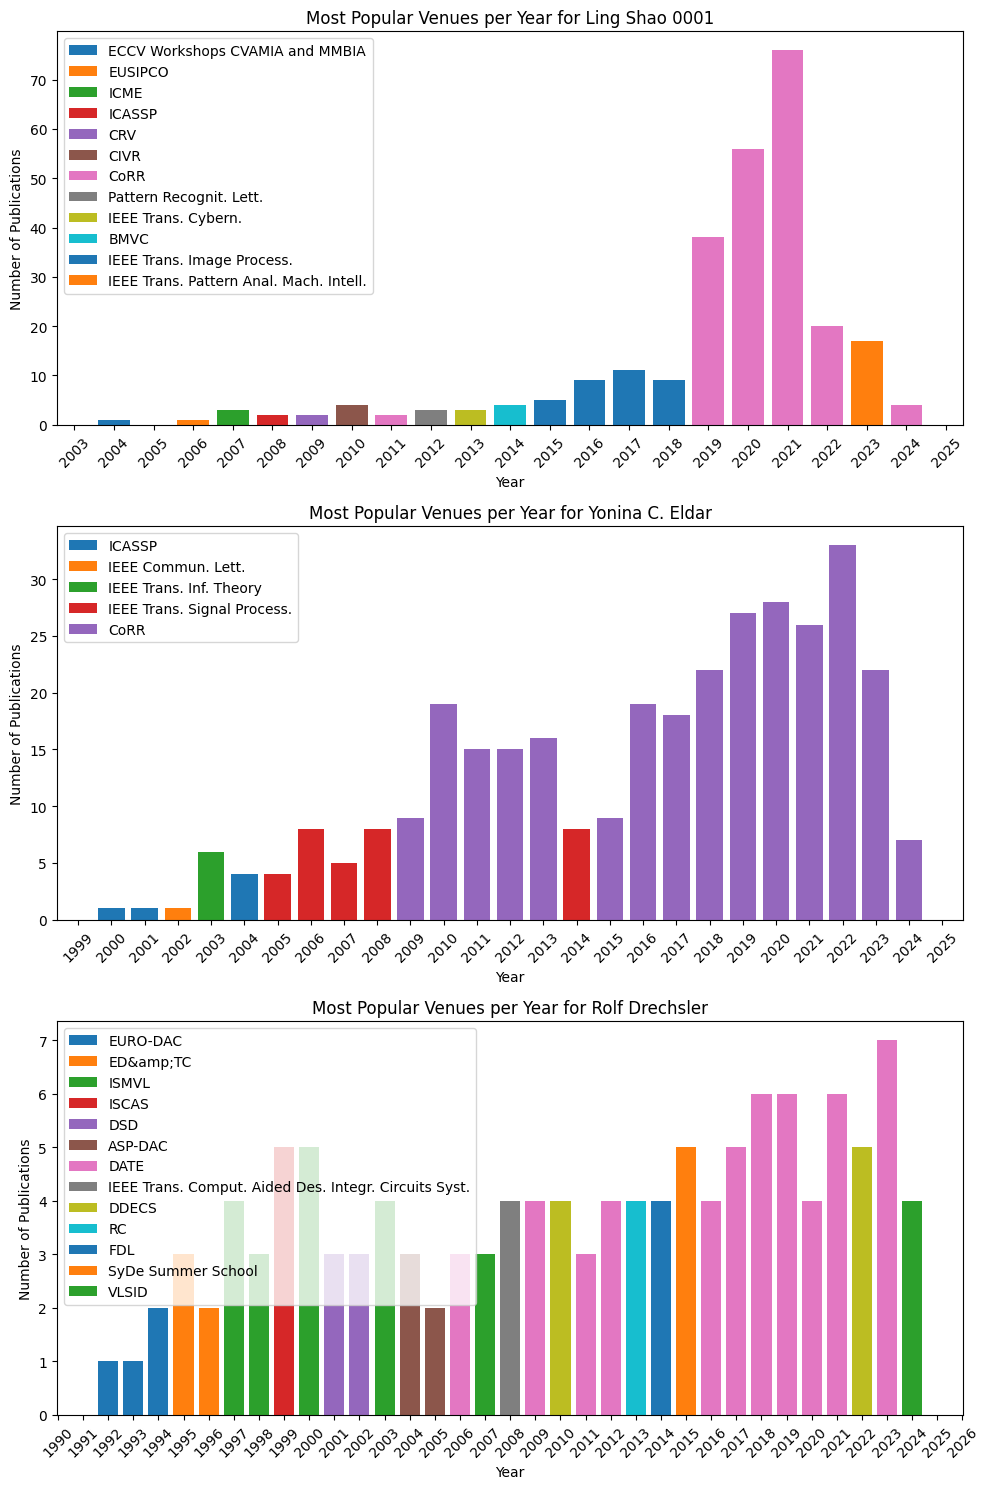

In [21]:
# Visualize the most popular venues per year using 'matplotlib.pyplot'
fig, ax = plt.subplots(nrows=len(authors), ncols=1, figsize=(10, 15))

for i, (df, auth) in enumerate(zip(most_popular_venues, authors)):
    # Convert 'info.year' column to numeric for completeness shake 
    df['info.year'] = pd.to_numeric(df['info.year'])

    # Iterate through unique venues to plot each one with its own color and label
    for venue in df['info.venue'].unique():
        # Filter data for the current venue
        venue_data = df[df['info.venue'] == venue]

        # Plot the bar chart for the current venue
        ax[i].bar(venue_data['info.year'], venue_data['count'], label=venue)

    # Set the title for each subplot
    ax[i].set_title(f"Most Popular Venues per Year for {auth}")

    # Set the x-axis label and rotate it by 45 degrees
    ax[i].set_xlabel('Year')
    ax[i].tick_params(axis='x', rotation=45)

    # Set the y-axis label
    ax[i].set_ylabel('Number of Publications')

    # Add a legend to each subplot
    ax[i].legend()
    
    # Use 'MultipleLocator' to set ticks on x-axis
    dtick = 1 
    ax[i].xaxis.set_major_locator(MultipleLocator(dtick))

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()

In [22]:
# Visualize the most popular venues per year for the third author
most_popular_venues[2]["info.year"] = pd.to_numeric(most_popular_venues[2]["info.year"])
fig = px.bar(most_popular_venues[2], x='info.year', y='count', color='info.venue')

fig.update_layout(
    xaxis_title='Year',
    yaxis_title='Number of Publications',
    title=f'Most Popular Venues per Year for {authors[2]}',
    xaxis=dict(
        tickangle=-45,
        tickmode='linear',
        dtick=1
    ), 
    bargap=0.2,
    height=900,
    width=1100
)

fig.show()

In [23]:
# Observe missing values in authors' column 
for df in merged_df:
    nan_values = df['info.authors.author'].isna()
    if nan_values.any():
        print("Indices with NaN values in column info.authors.author:")
        print(nan_values[nan_values].index)
    else:
        print(f"No NaN values in column info.authors.author")
    print("\n")

Indices with NaN values in column info.authors.author:
Index([885, 888, 893, 894, 895, 896], dtype='int64')


Indices with NaN values in column info.authors.author:
Index([832, 834, 835, 838, 855, 856, 864, 868, 870, 873, 888, 898, 899, 900,
       901, 902, 903, 910, 916, 923, 927, 929, 933, 934, 943, 944, 950, 951,
       955],
      dtype='int64')


Indices with NaN values in column info.authors.author:
Index([134, 168, 190, 234, 315, 458, 498, 772, 777, 790, 800, 802, 813, 824,
       838, 858, 860, 865, 888, 903, 905, 910, 924],
      dtype='int64')




In [24]:
# Create a dictionary where the keys are our main authors' names
# and the values are the authors involved in each publication
all_authors = {}

# Iterate through each dataframe and author name pair
for df, auth in zip(merged_df, authors):
    # Initialize an empty list of lists for the current author
    all_authors[auth] = []
    
    # Iterate through each publication's authors list
    for i in range(len(df['info.authors.author'])):
        authors_list = df['info.authors.author'][i]
        
        # Check for missing values (NaN is considered as float)
        if not isinstance(authors_list, float):
            # Collect each author's name in the current publication
            authors_collab = [authors_list[j]['text'] for j in range(len(authors_list))]
            
            # Remove the main author's name from the list of co-authors
            authors_collab.remove(auth)
        
        # Append the list of co-authors to the author's list of lists
        all_authors[auth].append(authors_collab)

# Print the dictionary of authors and their corresponding lists of co-authors
for author, colleagues in all_authors.items():
    print(f"Author: {author}")
    print("Co-authors per publication:")
    for coll in colleagues:
        print(coll)
    print("\n"*4)  # For readability between authors

Author: Ling Shao 0001
Co-authors per publication:
['Nikolaos V. Boulgouris', 'David R. Bull', 'Marco Cagnazzo', 'Andrea Cavallaro', 'Gene Cheung', 'Amit K. Roy-Chowdhury', 'Pedro Comesaña Alfaro', 'Shan Du', 'Sarp Ertürk', 'Markus Flierl', 'Gian Luca Foresti', 'Gang Hua 0001', 'Zhu Li 0001', 'Weisi Lin', 'Siwei Ma', 'Pramod Kumar Meher', 'Debargha Mukherjee', 'Aleksandra Pizurica', 'Andrea Prati 0001', 'Paolo Remagnino', 'Arun Ross', 'Shin&apos;ichi Satoh 0001', 'Andreas E. Savakis', 'Heiko Schwarz', 'Shervin Shirmohammadi', 'Giuseppe Valenzise', 'Meng Wang 0001', 'Zhou Wang 0001', 'Yonggang Wen 0001', 'Dong Xu 0001', 'Junsong Yuan', 'Yuan Yuan 0001']
['Abdelrahman Abdelhamed', 'Radu Timofte', 'Michael S. Brown', 'Songhyun Yu', 'Bumjun Park', 'Jechang Jeong', 'Seung-Won Jung', 'Dong-Wook Kim', 'Jae Ryun Chung', 'Jiaming Liu', 'Yuzhi Wang', 'Chi-Hao Wu 0001', 'Qin Xu', 'Chuan Wang 0001', 'Shaofan Cai', 'Yifan Ding', 'Haoqiang Fan', 'Jue Wang 0001', 'Kai Zhang 0008', 'Wangmeng Zuo', 'Ma

In [25]:
all_authors

{'Ling Shao 0001': [['Nikolaos V. Boulgouris',
   'David R. Bull',
   'Marco Cagnazzo',
   'Andrea Cavallaro',
   'Gene Cheung',
   'Amit K. Roy-Chowdhury',
   'Pedro Comesaña Alfaro',
   'Shan Du',
   'Sarp Ertürk',
   'Markus Flierl',
   'Gian Luca Foresti',
   'Gang Hua 0001',
   'Zhu Li 0001',
   'Weisi Lin',
   'Siwei Ma',
   'Pramod Kumar Meher',
   'Debargha Mukherjee',
   'Aleksandra Pizurica',
   'Andrea Prati 0001',
   'Paolo Remagnino',
   'Arun Ross',
   'Shin&apos;ichi Satoh 0001',
   'Andreas E. Savakis',
   'Heiko Schwarz',
   'Shervin Shirmohammadi',
   'Giuseppe Valenzise',
   'Meng Wang 0001',
   'Zhou Wang 0001',
   'Yonggang Wen 0001',
   'Dong Xu 0001',
   'Junsong Yuan',
   'Yuan Yuan 0001'],
  ['Abdelrahman Abdelhamed',
   'Radu Timofte',
   'Michael S. Brown',
   'Songhyun Yu',
   'Bumjun Park',
   'Jechang Jeong',
   'Seung-Won Jung',
   'Dong-Wook Kim',
   'Jae Ryun Chung',
   'Jiaming Liu',
   'Yuzhi Wang',
   'Chi-Hao Wu 0001',
   'Qin Xu',
   'Chuan Wang 00

In [25]:
# Initialize an empty dictionary to store all colleagues
all_colleagues = {}
for author, colleagues in all_authors.items():
    co_author_counts = {}
    for coll in colleagues:
        for co_author in coll:
            if co_author in co_author_counts:
                co_author_counts[co_author] += 1
            else:
                co_author_counts[co_author] = 1
    all_colleagues[author] = co_author_counts

for author, co_authors in all_colleagues.items():
    print(f"Most frequent colleagues for author {author}:")
    sorted_co_authors = sorted(co_authors.items(), key=lambda x: x[1], reverse=True)
    
    # Print the top N most frequent colleagues 
    N = 5 
    for i in range(min(N, len(sorted_co_authors))):
        print(f"{sorted_co_authors[i][0]}: {sorted_co_authors[i][1]} collaborations")
    print()  # For readability between authors

Most frequent colleagues for author Ling Shao 0001:
Li Liu 0004: 147 collaborations
Jianbing Shen: 104 collaborations
Fan Zhu 0001: 86 collaborations
Fahad Shahbaz Khan: 65 collaborations
Xiantong Zhen: 62 collaborations

Most frequent colleagues for author Yonina C. Eldar:
Nir Shlezinger: 148 collaborations
Andrea J. Goldsmith: 48 collaborations
Deborah Cohen: 34 collaborations
Moshe Mishali: 31 collaborations
Tianyao Huang: 30 collaborations

Most frequent colleagues for author Rolf Drechsler:
Robert Wille: 219 collaborations
Daniel Große: 176 collaborations
Mathias Soeken: 90 collaborations
Bernd Becker 0001: 81 collaborations
Görschwin Fey: 76 collaborations



In [27]:
all_colleagues

{'Ling Shao 0001': {'Nikolaos V. Boulgouris': 1,
  'David R. Bull': 1,
  'Marco Cagnazzo': 1,
  'Andrea Cavallaro': 1,
  'Gene Cheung': 1,
  'Amit K. Roy-Chowdhury': 1,
  'Pedro Comesaña Alfaro': 1,
  'Shan Du': 1,
  'Sarp Ertürk': 1,
  'Markus Flierl': 1,
  'Gian Luca Foresti': 1,
  'Gang Hua 0001': 1,
  'Zhu Li 0001': 1,
  'Weisi Lin': 1,
  'Siwei Ma': 1,
  'Pramod Kumar Meher': 1,
  'Debargha Mukherjee': 1,
  'Aleksandra Pizurica': 1,
  'Andrea Prati 0001': 1,
  'Paolo Remagnino': 1,
  'Arun Ross': 1,
  'Shin&apos;ichi Satoh 0001': 1,
  'Andreas E. Savakis': 1,
  'Heiko Schwarz': 1,
  'Shervin Shirmohammadi': 1,
  'Giuseppe Valenzise': 1,
  'Meng Wang 0001': 7,
  'Zhou Wang 0001': 1,
  'Yonggang Wen 0001': 1,
  'Dong Xu 0001': 6,
  'Junsong Yuan': 1,
  'Yuan Yuan 0001': 1,
  'Abdelrahman Abdelhamed': 1,
  'Radu Timofte': 7,
  'Michael S. Brown': 1,
  'Songhyun Yu': 1,
  'Bumjun Park': 1,
  'Jechang Jeong': 1,
  'Seung-Won Jung': 1,
  'Dong-Wook Kim': 1,
  'Jae Ryun Chung': 1,
  'Jia

In [26]:
# Initialize an empty dictionary to store the most frequent colleagues
most_frequent_colleagues = {}

for author, co_authors in all_colleagues.items():
    # Sort the co-authors dictionary by frequency (descending order)
    sorted_co_authors = sorted(co_authors.items(), key=lambda x: x[1], reverse=True)
    
    # Initialize a new dictionary for the top N most frequent co-authors
    top_n_co_authors = {}
    
    # Take the top N most frequent colleagues and add them to the dictionary
    N = 7 
    for i in range(min(N, len(sorted_co_authors))):
        co_author, frequency = sorted_co_authors[i]
        top_n_co_authors[co_author] = frequency
    
    # Store the dictionary of top N co-authors for the current author
    most_frequent_colleagues[author] = top_n_co_authors

In [27]:
most_frequent_colleagues

{'Ling Shao 0001': {'Li Liu 0004': 147,
  'Jianbing Shen': 104,
  'Fan Zhu 0001': 86,
  'Fahad Shahbaz Khan': 65,
  'Xiantong Zhen': 62,
  'Jungong Han': 44,
  'Deng-Ping Fan': 42},
 'Yonina C. Eldar': {'Nir Shlezinger': 148,
  'Andrea J. Goldsmith': 48,
  'Deborah Cohen': 34,
  'Moshe Mishali': 31,
  'Tianyao Huang': 30,
  'Ruud J. G. van Sloun': 29,
  'Ami Wiesel': 28},
 'Rolf Drechsler': {'Robert Wille': 219,
  'Daniel Große': 176,
  'Mathias Soeken': 90,
  'Bernd Becker 0001': 81,
  'Görschwin Fey': 76,
  'Vladimir Herdt': 68,
  'Wolfgang Günther 0001': 47}}

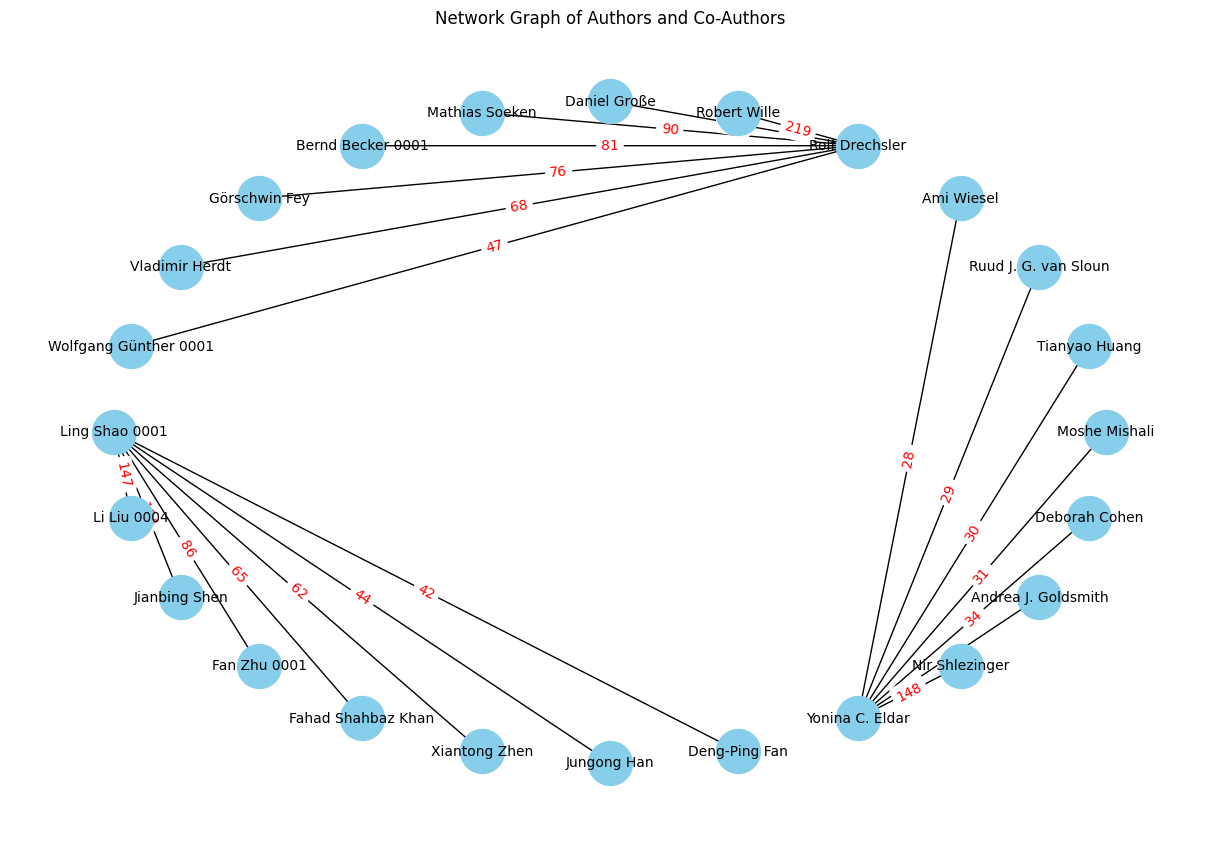

In [29]:
# Visualize the most frequent colleagues for each author with a Network Graph
G = nx.Graph()

# Add edges to the graph based on the most_frequent_colleagues data
for author, co_authors in most_frequent_colleagues.items():
    for co_author, count in co_authors.items():
        # Add an edge between the author and co-author with a weight equal to the count of collaborations
        G.add_edge(author, co_author, weight=count)

# Define the positions for the nodes 
pos = nx.shell_layout(G)  

# Draw the graph
plt.figure(figsize=(12, 8))
nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=1000, font_size=10, font_color='black')

# Draw edge labels (weights) on the graph
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

# Set a title
plt.title('Network Graph of Authors and Co-Authors')

# Show the plot
plt.show()

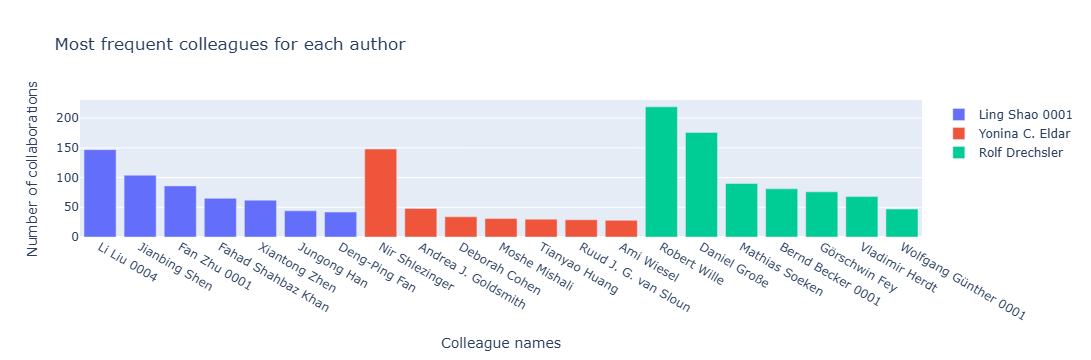

In [30]:
# # Visualize the most frequent colleagues for each author with a barplot
fig = go.Figure()

for author, colleagues in most_frequent_colleagues.items():
    co_auth = list(colleagues.keys())
    collabs = list(colleagues.values())
    fig.add_trace(
        go.Bar(
            x=co_auth,
            y=collabs,
            name=author
        )
    )

# 
fig.update_layout(
    title='Most frequent colleagues for each author',
    xaxis_title='Colleague names',
    yaxis_title='Number of collaborations'
)

fig.show()